<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import seaborn as sns
import openpyxl
df = pd.read_csv('Movies.csv', sep=',')

🔹 **Задание 1. Первичный анализ данных**

1. Загрузите файл в датафрейм и выведите первые 5 строк (Подсказка: найти в документации pandas, как читать csv файл, выставить разделителем запятую).
2. Первый столбец - индекс, который перезаписался как отдельный столбец: удалите его
3. Определите и выведите:

* количество строк и столбцов

* типы данных

* общую информацию по таблице и краткую статистику по числовым столбцам

* минимальное и максимальное значение по мировым сборам

* уникальные жанры

* количество фильмов по каждому рейтингу

In [2]:
df = df.drop(['Unnamed: 0'], axis=1)


In [3]:
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,"December 16, 2015",936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,"April 24, 2019",858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,"December 16, 2009",760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaN,700426566,647171407,1347597973,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,NaN
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaN,678815482,1369544272,2048359754,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,NaN


In [4]:
df.shape[0]

918

In [5]:
df.shape[1]

10

In [6]:
df.dtypes

Title                         object
Movie Info                    object
Distributor                   object
Release Date                  object
Domestic Sales (in $)          int64
International Sales (in $)     int64
World Sales (in $)             int64
Genre                         object
Movie Runtime                 object
License                       object
dtype: object

In [7]:
df.info

<bound method DataFrame.info of                                                  Title  \
0    Star Wars: Episode VII - The Force Awakens (2015)   
1                             Avengers: Endgame (2019)   
2                                        Avatar (2009)   
3                                 Black Panther (2018)   
4                        Avengers: Infinity War (2018)   
..                                                 ...   
913                                The Notebook (2004)   
914                   Jimmy Neutron: Boy Genius (2001)   
915                               Eat Pray Love (2010)   
916                 The Texas Chainsaw Massacre (2003)   
917                                   Zookeeper (2011)   

                                            Movie Info  \
0    As a new threat to the galaxy rises, Rey, a de...   
1    After the devastating events of Avengers: Infi...   
2    A paraplegic Marine dispatched to the moon Pan...   
3    T'Challa, heir to the hidden but a

In [8]:
df['International Sales (in $)'].min()

np.int64(260)

In [9]:
df['International Sales (in $)'].max()

np.int64(2086738578)

In [10]:
df['Distributor'].unique()

array(['Walt Disney Studios Motion Pictures', 'Twentieth Century Fox',
       'Sony Pictures Entertainment (SPE)', 'Paramount Pictures',
       'Universal Pictures', 'Warner Bros.', 'DreamWorks Distribution',
       'Lionsgate', 'DreamWorks', 'New Line Cinema', 'Newmarket Films',
       'Summit Entertainment', 'Columbia Pictures', 'IFC Films',
       'TriStar Pictures', 'Orion Pictures', 'Metro-Goldwyn-Mayer (MGM)',
       'Miramax', 'The Weinstein Company', 'Fox Searchlight Pictures',
       'Revolution Studios', 'Artisan Entertainment',
       'Sony Pictures Classics', 'United Artists', 'Screen Gems',
       'USA Films', '20th Century Studios', 'STX Entertainment',
       'Dimension Films', 'United Artists Releasing', 'FilmDistrict',
       'Focus Features', 'Relativity Media', 'Roadside Attractions'],
      dtype=object)

In [11]:
df['License'].value_counts()

License
PG-13    363
R        194
PG       173
G         14
Name: count, dtype: int64

🔹 **Задание 2. Обработка пропусков и создание новых признаков**

1. Проверьте, в каких столбцах есть пропуски.
2. Замените пропуски в столбце с рейтингом на самое частотное значение (Подсказка: заменить на mode()[0]).
3. Удалите все строки с пропусками в дате релиза.
3. Добавьте новый столбец: доля домашних сборов относительно мировых.

In [12]:
df.isna().sum()

Title                           0
Movie Info                      0
Distributor                     0
Release Date                  118
Domestic Sales (in $)           0
International Sales (in $)      0
World Sales (in $)              0
Genre                           0
Movie Runtime                   0
License                       174
dtype: int64

In [13]:
median_value = df['License'].mode()[0]
df['License'].fillna(median_value, inplace=True)
df.isna().sum()

/var/folders/7c/31qz061x195d5qkrqjg973v00000gn/T/ipykernel_37808/1138943990.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['License'].fillna(median_value, inplace=True)


Title                           0
Movie Info                      0
Distributor                     0
Release Date                  118
Domestic Sales (in $)           0
International Sales (in $)      0
World Sales (in $)              0
Genre                           0
Movie Runtime                   0
License                         0
dtype: int64

In [14]:
df.insert(7,'New', (df['World Sales (in $)'] * 100 / df['Domestic Sales (in $)']))
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),New,Genre,Movie Runtime,License
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,"December 16, 2015",936662225,1132859475,2069521700,220.946425,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,"April 24, 2019",858373000,1939128328,2797501328,325.907423,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,"December 16, 2009",760507625,2086738578,2847246203,374.387594,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaN,700426566,647171407,1347597973,192.396753,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,PG-13
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaN,678815482,1369544272,2048359754,301.755014,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,PG-13


In [15]:
df['Release Date'] = pd.to_datetime(df['Release Date'])
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),New,Genre,Movie Runtime,License
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,220.946425,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,325.907423,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,374.387594,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaT,700426566,647171407,1347597973,192.396753,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,PG-13
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaT,678815482,1369544272,2048359754,301.755014,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,PG-13


🔹 **Задание 3. Работа с датами**

1. Преобразуйте столбец Release Date в тип datetime (Подсказка: найти в документации pandas, как вызывать функцию to_datetime).
2. Добавьте новый столбец Year, извлекая из даты только год (Подсказка: найти в документации pandas, как вызывать функцию dt.year).

In [16]:
df['Release Date'] = pd.to_datetime(df['Release Date'])
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),New,Genre,Movie Runtime,License
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,220.946425,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,325.907423,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,374.387594,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaT,700426566,647171407,1347597973,192.396753,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,PG-13
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaT,678815482,1369544272,2048359754,301.755014,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,PG-13


In [17]:
df['Year'] = df['Release Date'].dt.year
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),New,Genre,Movie Runtime,License,Year
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,220.946425,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,2015.0
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,325.907423,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,2019.0
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,374.387594,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,2009.0
3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaT,700426566,647171407,1347597973,192.396753,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,PG-13,NaN
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaT,678815482,1369544272,2048359754,301.755014,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,PG-13,NaN


🔹 **Задание 4. Фильтрация данных и срезы**

1. Найдите и выведите фильмы с 10 по 20 строку:

* с домашними сборами больше 70 миллионов (только столбцы с названиями фильмов и домашними сборами)

* со мстителями (в названии есть "Avengers") (только столбцы с названиями фильмов и описанием)

* 20-ого века и студии Paramount Pictures (только столбцы с названиями фильмов, годом и студией)

2. Отсортируйте и пересохраните таблицу в порядке убывания мировых сборов.

In [18]:
df.iloc[10:21]

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),New,Genre,Movie Runtime,License,Year
10,Incredibles 2 (2018),The Incredibles family takes on a new mission ...,Walt Disney Studios Motion Pictures,NaT,608581744,634507500,1243089244,204.260029,"['Action', 'Adventure', 'Animation', 'Comedy',...",1 hr 58 min,PG-13,NaN
11,The Lion King (2019),"After the murder of his father, a young lion p...",Walt Disney Studios Motion Pictures,2019-07-11,543638043,1119261396,1662899439,305.883567,"['Adventure', 'Animation', 'Drama', 'Family', ...",1 hr 58 min,PG,2019.0
12,The Dark Knight (2008),When the menace known as the Joker wreaks havo...,Warner Bros.,2008-07-16,534858444,471115201,1005973645,188.082222,"['Action', 'Crime', 'Drama', 'Thriller']",2 hr 32 min,PG-13,2008.0
13,Rogue One: A Star Wars Story (2016),"In a time of conflict, a group of unlikely her...",Walt Disney Studios Motion Pictures,2016-12-14,532177324,523880396,1056057720,198.440947,"['Action', 'Adventure', 'Sci-Fi']",2 hr 13 min,PG-13,2016.0
14,Star Wars: Episode IX - The Rise of Skywalker ...,In the riveting conclusion of the landmark Sky...,Walt Disney Studios Motion Pictures,2019-12-18,515202542,558946737,1074149279,208.490679,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 21 min,PG-13,2019.0
15,Beauty and the Beast (2017),A selfish Prince is cursed to become a monster...,Walt Disney Studios Motion Pictures,2017-03-16,504481165,769095055,1273576220,252.452680,"['Adventure', 'Family', 'Fantasy', 'Musical', ...",2 hr 9 min,PG,2017.0
16,Finding Dory (2016),Friendly but forgetful blue tang Dory begins a...,Walt Disney Studios Motion Pictures,NaT,486295561,542275381,1028570942,211.511481,"['Adventure', 'Animation', 'Comedy', 'Family']",1 hr 37 min,PG-13,NaN
17,Frozen II (2019),"Anna, Elsa, Kristoff, Olaf and Sven leave Aren...",Walt Disney Studios Motion Pictures,2019-11-20,477373578,972653355,1450026933,303.750982,"['Adventure', 'Animation', 'Comedy', 'Family',...",1 hr 43 min,PG,2019.0
18,Star Wars: Episode I - The Phantom Menace (1999),Two Jedi escape a hostile blockade to find all...,Twentieth Century Fox,1999-05-19,474544677,552538030,1027082707,216.435408,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 16 min,PG,1999.0
19,Star Wars: Episode IV - A New Hope (1977),Luke Skywalker joins forces with a Jedi Knight...,Twentieth Century Fox,1977-05-25,460998507,195751992,775398007,168.199679,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 1 min,PG,1977.0


In [19]:
df.loc[df['Domestic Sales (in $)'] > 70000000, ['Title', 'Domestic Sales (in $)']]

,Title,Domestic Sales (in $)
0,Star Wars: Episode VII - The Force Awakens (2015),936662225
1,Avengers: Endgame (2019),858373000
2,Avatar (2009),760507625
3,Black Panther (2018),700426566
4,Avengers: Infinity War (2018),678815482
...,...,...
913,The Notebook (2004),81001787
914,Jimmy Neutron: Boy Genius (2001),80936232
915,Eat Pray Love (2010),80574010
916,The Texas Chainsaw Massacre (2003),80571655


In [20]:
df.loc[df['Title'].str.contains('Avengers'), ['Title', 'Movie Info']]

,Title,Movie Info
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...
8,The Avengers (2012),Earth's mightiest heroes must come together an...
20,Avengers: Age of Ultron (2015),When Tony Stark and Bruce Banner try to jump-s...


In [21]:
df.loc[df['Year'] > 1899.0, ['Title', 'Movie Info', 'Year']]

,Title,Movie Info,Year
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",2015.0
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,2019.0
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,2009.0
6,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,1997.0
7,Jurassic World (2015),"A new theme park, built on the original site o...",2015.0
...,...,...,...
913,The Notebook (2004),A poor yet passionate young man falls in love ...,2004.0
914,Jimmy Neutron: Boy Genius (2001),An eight-year-old boy genius and his friends m...,2001.0
915,Eat Pray Love (2010),A married woman realizes how unhappy her marri...,2010.0
916,The Texas Chainsaw Massacre (2003),After picking up a traumatized young hitchhike...,2003.0


In [22]:
df.sort_values(by='World Sales (in $)', ascending=False)

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),New,Genre,Movie Runtime,License,Year
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,374.387594,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,2009.0
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,325.907423,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,2019.0
6,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,333.904710,"['Drama', 'Romance']",3 hr 14 min,PG-13,1997.0
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,220.946425,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,2015.0
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaT,678815482,1369544272,2048359754,301.755014,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,PG-13,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
831,The Naked Gun 2½: The Smell of Fear (1991),Lieutenant Frank Drebin discovers that his ex-...,Paramount Pictures,1991-06-28,86930411,86930411,86930411,100.000000,"['Comedy', 'Crime']",1 hr 25 min,PG-13,1991.0
874,I Can Only Imagine (2018),The inspiring and unknown true story behind Me...,Roadside Attractions,2018-03-15,83482352,2604529,86086881,103.119856,"['Biography', 'Drama', 'Family', 'Music']",1 hr 50 min,PG,2018.0
847,Stripes (1981),Two friends who are dissatisfied with their jo...,Columbia Pictures,NaT,85297000,85297000,85297000,100.000000,"['Comedy', 'War']",1 hr 46 min,PG-13,NaN
888,Star Trek: The Motion Picture (1979),When an alien spacecraft of enormous power is ...,Paramount Pictures,1979-12-07,82604699,82604699,82604699,100.000000,"['Adventure', 'Mystery', 'Sci-Fi']",2 hr 12 min,G,1979.0


🔹 **Задание 5. Группировка, агрегация и визуализация**

1. Создайте таблицу с группировкой: сколько фильмов вышло в каждом году.
2. Постройте график по этим данным с:
* подписями осей
* названием графика
* сеткой

3. Создайте таблицу с двойной группировкой: сколько суммарно общемировых сборов собрала каждая студия, сколько фильмов каждая студия сняла.
4. Постройте сабплоты: две столбчатые диаграммы друг под другом по этим данным с:
* размером фигуры 12 * 12
* подписями осей
* названием графика
* цветовой палитрой
* повернутыми на 90 градусов лейблами на оси X
* перед выводом графика добавьте plt.tight_layot(), чтобы графики не накладывались друг на друга

In [23]:
df_plot = (df.groupby('Year')['Title'].count())
df_plot

Year
1972.0     1
1975.0     1
1977.0     1
1978.0     2
1979.0     2
1980.0     1
1981.0     2
1982.0     2
1983.0     2
1984.0     2
1985.0     1
1986.0     1
1987.0     1
1988.0     4
1989.0     3
1990.0    11
1991.0     9
1992.0     9
1993.0     6
1994.0    12
1995.0     6
1996.0    10
1997.0    13
1998.0    17
1999.0    27
2000.0    26
2001.0    26
2002.0    32
2003.0    36
2004.0    30
2005.0    22
2006.0    23
2007.0    27
2008.0    35
2009.0    37
2010.0    39
2011.0    34
2012.0    36
2013.0    40
2014.0    41
2015.0    35
2016.0    33
2017.0    32
2018.0    31
2019.0    35
2020.0     3
2021.0     1
Name: Title, dtype: int64

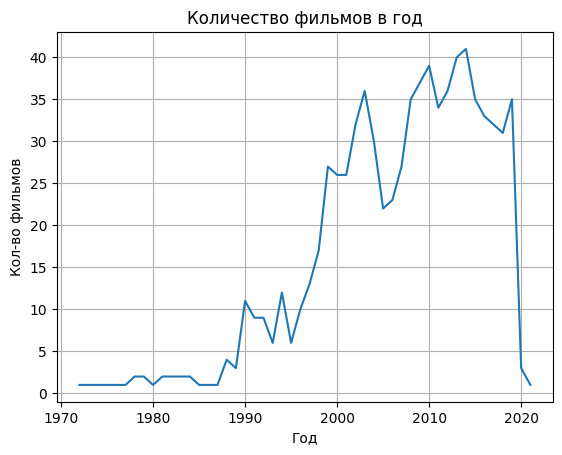

In [24]:
df_plot.plot()
plt.title('Количество фильмов в год')
plt.xlabel('Год')
plt.ylabel('Кол-во фильмов')
plt.grid()

In [25]:
df.groupby(['Distributor']).agg(Cash=('World Sales (in $)', 'sum'), Films=('Title', 'count'))

,Cash,Films
Distributor,,
20th Century Studios,331503757,1
Artisan Entertainment,248639099,1
Columbia Pictures,1374209626,7
Dimension Films,1223005113,7
DreamWorks,10412975902,21
DreamWorks Distribution,5814639953,17
FilmDistrict,332189519,2
Focus Features,415922809,2
Fox Searchlight Pictures,1117424454,4


In [26]:
plt.figure(figsize=(12,12))



<Figure size 1200x1200 with 0 Axes>

<Figure size 1200x1200 with 0 Axes>

🔹 **Задание 6. Кастомные функции и применение apply()**

1. Напишите функцию movie_runtime_minutes, которая переведет длительность фильмов из текстового формата в минуты:
* как один из вариантов, можно найти оба числа, то есть часы и минуты, с помощью re.findall("[0-9]{1, }", x), не забыв импортировать библиотеку re
* сохранить это как список, затем умножить первое число (час) из списка на 60, прибавить второе число (минуты): не забыть учесть, что не во всех фильмах указаны минуты - значит, нужно прописать отдельные условия, если есть и часы, и минуты, или есть только часы
* не забыть, что элементы в списке - строковые, нужно перевести их в числа: условно будет int(numbers[0])*60 + ...
2. Примените функцию к таблице, создав новый столбец Movie Runtime Minutes.

In [27]:
def movie_runtime_minutes(x):
    lst = re.findall("[0-9]{1, }", x['Movie Runtime'])
    if len(lst) > 1:
        minutes = r'd+ hr'*60 + r'd+ min'
    else:
        minutes =  r'd+ hr'*60
    return minutes

df['Movie Runtime Minutes'] = df.apply(movie_runtime_minutes, axis=1)
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),New,Genre,Movie Runtime,License,Year,Movie Runtime Minutes
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,220.946425,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,2015.0,d+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd...
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,325.907423,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,2019.0,d+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd...
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,374.387594,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,2009.0,d+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd...
3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaT,700426566,647171407,1347597973,192.396753,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,PG-13,NaN,d+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd...
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaT,678815482,1369544272,2048359754,301.755014,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,PG-13,NaN,d+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd+ hrd...


🔹 **Задание 7. Визуализация корреляций**

1. Выведите корреляционную матрицу по числовым признакам в таблице.
2. Постройте тепловую карту по этим данным с названием графика.
3. Напишите в отдельной ячейке markdown, есть ли взаимосвязь между продолжительностью фильма и его сборами?
4. Постройте диаграмму рассеяния между признаками, у которых наибольшая корреляция (Подсказка: в документации найдите matplotlib scatter, какие обязательные параметры туда нужно передать).
5. Сохраните итоговую таблицу в excel.

In [28]:
correlation = df.corr(numeric_only=True)


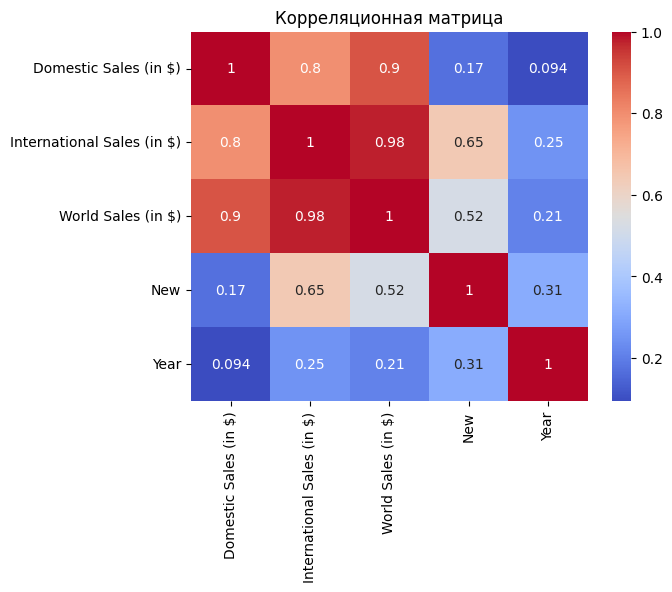

In [29]:
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица')
plt.show()

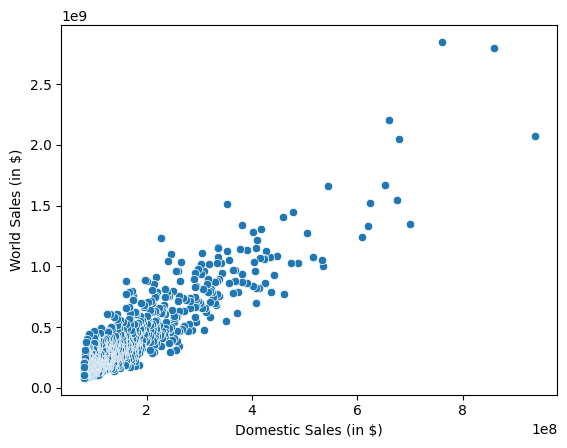

In [30]:
sns.scatterplot(x='Domestic Sales (in $)', y='World Sales (in $)', data=df)
plt.show()

In [31]:
df.to_excel('итоговая таблица.xlsx', index=False)